# Financial Product Portfolio Construction

In [1]:
from ast import Index
from multiprocessing.managers import Value

import src.utils.file_management as filemgmt
from src.pipeline.chatbot import WhatsAppChatbot
from src.pipeline.preprocessing import StockPriceDataManager
from src.pipeline.financial_products import KOCertificate, KOCertificateSet

import pandas as pd
import numpy as np

from selenium.common.exceptions import TimeoutException

from pathlib import Path
from tqdm import tqdm

In [2]:
ROOT = Path().resolve().parent

DATA = ROOT / "data"
DOWNLOADED_PRICES = DATA / "minutely_price_downloads"
INTERPOLATED_PRICES = DATA / "interpolated_prices_dax"

SAVED_PORTFOLIOS = DATA / "portfolios"

PRIVATE_FILES = ROOT / "private"
AV_API_KEY_FILE = PRIVATE_FILES / "Alpha Vantage API Key.txt"
with open(AV_API_KEY_FILE) as file: AV_API_KEY = file.read()

## DataManager

In [7]:
from src.pipeline.chatbot import WhatsAppChatbot
chatter = WhatsAppChatbot(PRIVATE_FILES / "chatbot.env")

In [10]:
chatter("HI")

In [4]:
from functools import wraps
import time

def retry_decorator(exceptions=(ValueError, AttributeError, IndexError), on_error_callback: callable = print, retries: int = 3, delay: int = 1):
    """
    Creates a decorator to automatically retry a function upon encountering specified exceptions.

    Parameters
    ----------
    exceptions : tuple, optional
        Exceptions to catch for retrying the function, by default (ValueError, AttributeError, IndexError).
    on_error_callback : callable, optional
        A callback function that receives error messages when an exception occurs, by default None.
    retries : int, optional
        The maximum number of retry attempts before raising the exception, by default 3.
    delay : int, optional
        The delay in seconds between retry attempts, by default 1.

    Returns
    -------
    callable
        A decorator that wraps the specified function with retry logic.
    """

    def decorator(func):
        @wraps(func)
        def wrapper(*args, **kwargs):
            attempts = 0
            while attempts < retries:
                try:
                    return func(*args, **kwargs)
                except exceptions as e:
                    attempts += 1
                    error_message = f"Starting attempt {attempts} because of error: {str(e)}"
                    if on_error_callback is not None: on_error_callback(error_message)

                    if attempts >= retries:
                        raise  # Re-raise the exception after max retries
                    time.sleep(delay)  # Optional delay between retries

        return wrapper

    return decorator

In [23]:
import time
from functools import wraps
from threading import Thread, Event


def timed_callback_decorator(callback: callable = print, interval_minutes=1):
    """
    Function decorator that times the wrapped function and executes a callback periodically.
    
    Parameters
    ----------
    callback : Callable
        A callback function to be executed periodically to report status. The callback should accept a single string argument for the message.

    interval_minutes : int, optional
        The time interval in minutes between consecutive executions of the callback function. Defaults to 1 minute.
    """
    def decorator(func):
        @wraps(func)
        def wrapper(*args, **kwargs):
            # Variables to track time and stop the callback thread
            start_time = time.time()
            stop_event = Event()

            def report_status():
                # Periodically calls the callback every `interval_minutes`
                while not stop_event.is_set():
                    time.sleep(interval_minutes * 60)  # Wait for the interval
                    elapsed_time = time.time() - start_time
                    if not stop_event.is_set():
                        callback(f"Function `{func.__name__}` running for {elapsed_time / 60:.2f} minutes...")

            # Start the thread that handles periodic callback execution
            status_thread = Thread(target=report_status)
            status_thread.start()

            try:
                # Execute the main function
                result = func(*args, **kwargs)
            finally:
                # Stop the status thread after the function finishes
                stop_event.set()
                status_thread.join()
            return result

        return wrapper
    
    return decorator

In [24]:
@timed_callback_decorator(callback=chatter, interval_minutes=1)
@retry_decorator(exceptions=(ValueError,),
                  on_error_callback=chatter,
                  retries=3, delay=1)
def say_hello():
    """
    say_hello()

    A function that is decorated with `retry_decorator`. This decorator allows the function
    to be retried a specified number of times in case a given exception is raised. 

    The decorator parameters are:
    - exceptions: A tuple of exceptions that trigger a retry. In this case, it catches the `ValueError`.
    - on_error_callback: A callback function invoked whenever an exception occurs.
    - retries: The total number of retry attempts.
    - delay: The delay (in seconds) between retry attempts.

    Raises
    ------
    ValueError
        If the function ultimately fails after the specified retry attempts.
    """
    time.sleep(10)
    print("Hello, world!")
    time.sleep(60)
    raise ValueError("Incompatible types!")

In [25]:
say_hello()

Hello, world!
Hello, world!


KeyboardInterrupt: 

In [4]:
data_manager = StockPriceDataManager(ticker_symbol='DAX',
                                    download_dir=DOWNLOADED_PRICES,
                                    interpolated_files_dir=INTERPOLATED_PRICES,
                                    alpha_vantage_api_key=AV_API_KEY,
                                    env_sampling_rate_minutes=15,
                                    is_etf_price_data=True,
                                    non_etf_time_price_tuples=[('2025-06-04 18:00:00', 24276.48),
                                                               ('2025-06-02 17:00:00', 23942.52),
                                                               ('2025-06-03 12:00:00', 23962.40),
                                                               ('2025-05-30 17:00:00', 23997.71)]
                                    )

## Scrape Real Products
Wikifolio trades ko-certificates from Societe Generale and HSBC.

In [23]:
from itertools import combinations

In [35]:
presets_to_consider = ("b1", "b2", "c1", "c2", "d1", "d2", "d3")
n_predictors_range = (1, 4)

combs_to_backtest = []

counter = 0
for number_of_presets in range(n_predictors_range[0], n_predictors_range[1] + 1):
    for comb in combinations(presets_to_consider, r=number_of_presets):
        combs_to_backtest.append(comb)
    
print(combs_to_backtest)

[('b1',), ('b2',), ('c1',), ('c2',), ('d1',), ('d2',), ('d3',), ('b1', 'b2'), ('b1', 'c1'), ('b1', 'c2'), ('b1', 'd1'), ('b1', 'd2'), ('b1', 'd3'), ('b2', 'c1'), ('b2', 'c2'), ('b2', 'd1'), ('b2', 'd2'), ('b2', 'd3'), ('c1', 'c2'), ('c1', 'd1'), ('c1', 'd2'), ('c1', 'd3'), ('c2', 'd1'), ('c2', 'd2'), ('c2', 'd3'), ('d1', 'd2'), ('d1', 'd3'), ('d2', 'd3'), ('b1', 'b2', 'c1'), ('b1', 'b2', 'c2'), ('b1', 'b2', 'd1'), ('b1', 'b2', 'd2'), ('b1', 'b2', 'd3'), ('b1', 'c1', 'c2'), ('b1', 'c1', 'd1'), ('b1', 'c1', 'd2'), ('b1', 'c1', 'd3'), ('b1', 'c2', 'd1'), ('b1', 'c2', 'd2'), ('b1', 'c2', 'd3'), ('b1', 'd1', 'd2'), ('b1', 'd1', 'd3'), ('b1', 'd2', 'd3'), ('b2', 'c1', 'c2'), ('b2', 'c1', 'd1'), ('b2', 'c1', 'd2'), ('b2', 'c1', 'd3'), ('b2', 'c2', 'd1'), ('b2', 'c2', 'd2'), ('b2', 'c2', 'd3'), ('b2', 'd1', 'd2'), ('b2', 'd1', 'd3'), ('b2', 'd2', 'd3'), ('c1', 'c2', 'd1'), ('c1', 'c2', 'd2'), ('c1', 'c2', 'd3'), ('c1', 'd1', 'd2'), ('c1', 'd1', 'd3'), ('c1', 'd2', 'd3'), ('c2', 'd1', 'd2'), ('

In [38]:
from src.pipeline.predictors import PredictorManager
SAVED_MODELS = DATA / "saved_models"
SAVED_LSTM_MODELS = SAVED_MODELS / "lstm"
SAVED_TF_MODELS = SAVED_MODELS / "transformer"
WORKING_DIR_PREDICTORS = SAVED_MODELS / "working_dir_pred_manager"
pred_manager = PredictorManager(data_manager=data_manager, initialisation_dir=SAVED_MODELS, recursive=True,
                                not_older_than_n_days=7,  # only recently fine-tuned models
                                )

In [45]:
pred_manager.get_predictors_by_type_sorted(return_instances=False, architecture="lstm")

[]

In [47]:
predictor_list = []
for comb in combs_to_backtest:
    list_entry = []
    for preset in comb:
        try:
            list_entry.append(pred_manager.get_predictors_by_type_sorted(architecture="LSTM", preset_type=preset, return_instances=True, k_best=1)[0])
        except IndexError:
            print(f"No predictor found for {preset} in {comb}. Skipping.")
    predictor_list.append(list_entry)

No predictor found for b1 in ('b1',). Skipping.
No predictor found for b2 in ('b2',). Skipping.
No predictor found for b1 in ('b1', 'b2'). Skipping.
No predictor found for b2 in ('b1', 'b2'). Skipping.
No predictor found for b1 in ('b1', 'c1'). Skipping.
No predictor found for b1 in ('b1', 'c2'). Skipping.
No predictor found for b1 in ('b1', 'd1'). Skipping.
No predictor found for b1 in ('b1', 'd2'). Skipping.
No predictor found for b1 in ('b1', 'd3'). Skipping.
No predictor found for b2 in ('b2', 'c1'). Skipping.
No predictor found for b2 in ('b2', 'c2'). Skipping.
No predictor found for b2 in ('b2', 'd1'). Skipping.
No predictor found for b2 in ('b2', 'd2'). Skipping.
No predictor found for b2 in ('b2', 'd3'). Skipping.
No predictor found for b1 in ('b1', 'b2', 'c1'). Skipping.
No predictor found for b2 in ('b1', 'b2', 'c1'). Skipping.
No predictor found for b1 in ('b1', 'b2', 'c2'). Skipping.
No predictor found for b2 in ('b1', 'b2', 'c2'). Skipping.
No predictor found for b1 in ('b

In [9]:
from datetime import datetime

ko_certificate_list = []
for isin, direction, date_price in tqdm(zip(
        ["DE000TT2CH77", "DE000HS3U0K3", "DE000TB192G9", "DE000TT0ZP72", "DE000TT1K2J8",
         "DE000TT1WHV8", "DE000HG75555", "DE000HS2W424", "DE000HS3GYD5", "DE000HS8DSJ0",
         "DE000HT42LT9", "DE000FA61D63", "DE000FA0RD26", "DE000FA0Q232", "DE000SX0LHS4",
         "DE000SX0LHS4", "DE000HT52AV7", "DE000HT52AV7"],
        ["long", "long", "long", "long", "long",
         "long", "long", "long", "long", "long",
         "long", "short", "short", "short", "short",
         "short", "short", "short"],
        [("2022-09-26", 6.49), ("2024-08-05", 0.81), ("2022-09-26", 85.27), ("2023-10-23", 62.97), ("2025-04-22", 134.23),
         ("2023-10-23", 36.33), ("2023-10-23", 15.98), ("2024-08-23", 2.22), ("2024-08-05", 1.34), ("2025-03-31", 2.38),
         ("2025-04-09", 0.83), ("2025-07-22", 111.01), ("2025-07-09", 93.60), ("2025-07-09", 78.45),
         ("2025-03-18", 80.9),
         ("2025-03-18", 70.19), ("2025-07-09", 50.85), ("2025-07-09", 4.43)
         ])):
    try:
        ko_certificate = KOCertificate(
            underlying_price_series=data_manager.non_etf_env_interp_prices,
            isin=isin,
            direction=direction,
            historic_date_future_price_tuple=None, #date_price
        )
        # if necessary, fix initial knockout by shortening issue_date
        ko_certificate.issue_date = datetime.now() - pd.Timedelta(days=50)
        ko_certificate.enforce_base_price_increase_per_annum(.03)
        #ko_certificate.fix_initial_knockout(by='issue_date', abs_base_price_change_pa=.03)
        if ko_certificate.timestamp_last_ko_breach is not None:  # if KO remains
            ko_certificate.enforce_base_price_increase_per_annum(.03)
            
        ko_certificate_list.append(ko_certificate)
        
    except (KeyError, TypeError, TimeoutException, IndexError) as e:
        print(f"Error occurred for ISIN {isin}: {e}. Skipping this ISIN.")

portfolio = KOCertificateSet(ko_certificates=ko_certificate_list)

18it [01:56,  6.47s/it]


In [10]:
for product in portfolio.ko_certificates:
    print(product.isin, product.timestamp_last_ko_breach, product.issue_date, product.direction)

DE000TT2CH77 None 2025-07-27 21:30:34.798021 long
DE000HS3U0K3 None 2025-07-27 21:30:41.130576 long
DE000TB192G9 None 2025-07-27 21:30:47.254966 long
DE000TT0ZP72 None 2025-07-27 21:30:54.215932 long
DE000TT1K2J8 None 2025-07-27 21:31:00.478276 long
DE000TT1WHV8 None 2025-07-27 21:31:06.334445 long
DE000HG75555 None 2025-07-27 21:31:12.320617 long
DE000HS2W424 None 2025-07-27 21:31:18.391669 long
DE000HS3GYD5 None 2025-07-27 21:31:24.924711 long
DE000HS8DSJ0 None 2025-07-27 21:31:31.284287 long
DE000HT42LT9 None 2025-07-27 21:31:37.292049 long
DE000FA61D63 None 2025-07-27 21:31:47.672885 short
DE000FA0RD26 None 2025-07-27 21:31:53.739858 short
DE000FA0Q232 None 2025-07-27 21:31:59.793369 short
DE000SX0LHS4 None 2025-07-27 21:32:06.009718 short
DE000SX0LHS4 None 2025-07-27 21:32:11.993522 short
DE000HT52AV7 None 2025-07-27 21:32:18.242308 short
DE000HT52AV7 None 2025-07-27 21:32:24.385489 short


In [11]:
portfolio.get_leverage_availability("long", since_date="2025-08-20", hour_minute_to_check=(16, 0), verbose=False)

,1.0,2.0,3.0,4.0
date,,,,
2025-08-20 16:00:00,True,True,True,True
2025-08-21 16:00:00,True,True,True,True
2025-08-22 16:00:00,True,True,True,True
2025-08-25 16:00:00,True,True,True,True
2025-08-26 16:00:00,True,True,True,True
2025-08-27 16:00:00,True,True,True,True
2025-08-28 16:00:00,True,True,True,True
2025-08-29 16:00:00,True,True,True,True
2025-09-01 16:00:00,True,True,True,True


In [35]:
portfolio.by_isin['DE000HT52AV7'].date_base_price_tuple2 = ("2025-07-09", 25300)
back_up_product = portfolio.by_isin['DE000HT52AV7']

In [12]:
portfolio.by_isin['DE000HT52AV7'].enforce_base_price_increase_per_annum()

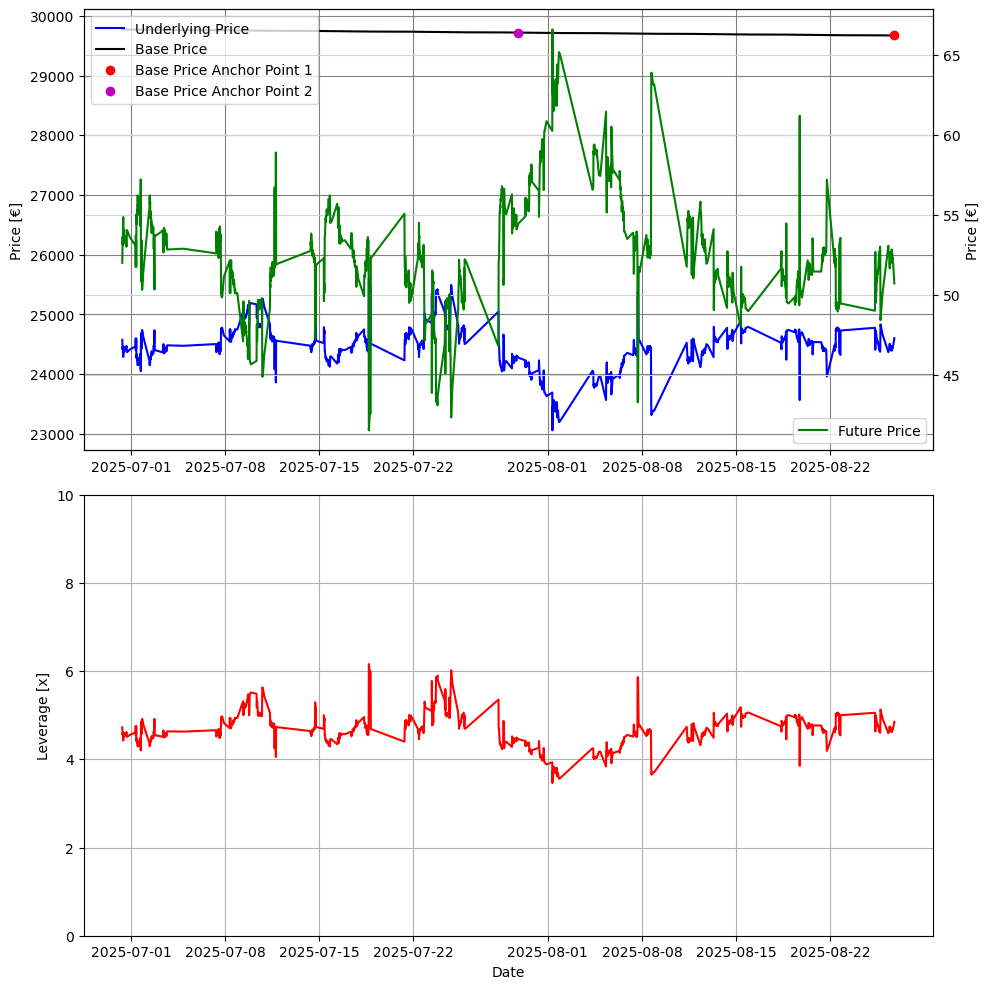

In [13]:
portfolio.by_isin['DE000HT52AV7'].plot()

In [ ]:
portfolio.by_isin['DE000HT52AV7'].issue_date = "2025-04-09"

In [10]:
portfolio.by_isin['DE000HT52AV7'].enforce_base_price_increase_per_annum()

In [11]:
portfolio.by_isin['DE000HT52AV7'].base_price_change_per_annum

-0.020000000000000684

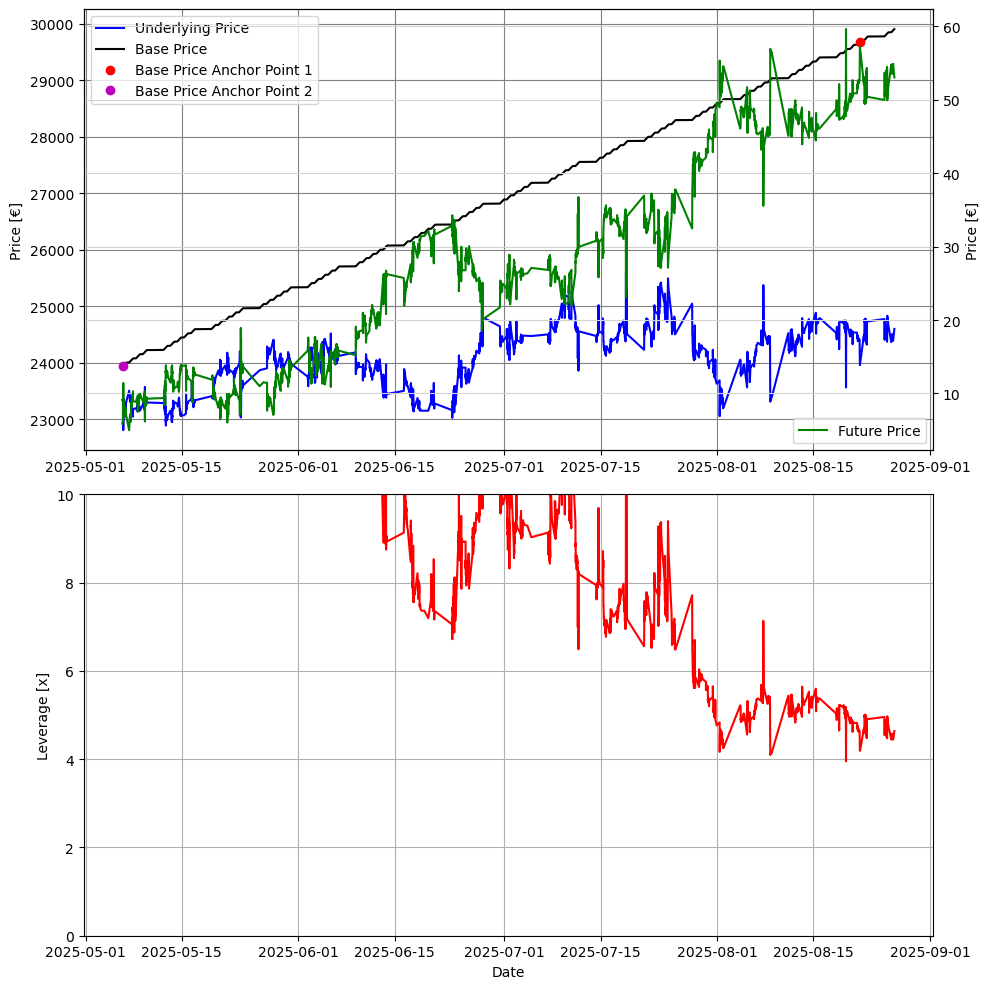

In [8]:
portfolio.by_isin['DE000HT52AV7'].plot()

In [21]:
portfolio.by_isin['DE000HS8DSJ0'].issue_date = "2025-04-09"

portfolio.by_isin['DE000HS8DSJ0'].get_base_price_from_future_price(date="2025-08-01", future_price=5.2, use_as_2nd_base_price_tuple=True)

np.float64(18313.95292027193)

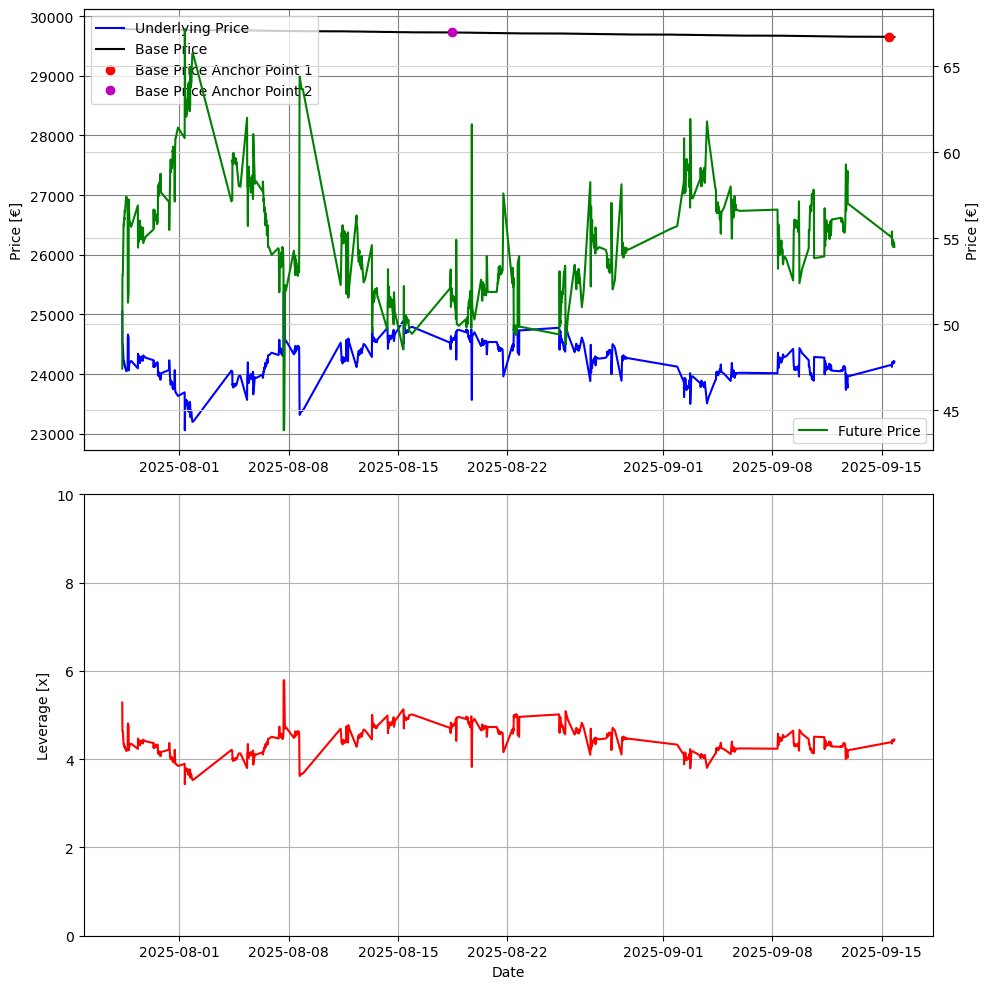

In [12]:
portfolio.by_isin['DE000HT52AV7'].plot()

In [5]:
for product in portfolio.ko_certificates:
    print(product.isin, product.timestamp_last_ko_breach, product.base_price_change_per_annum, product.direction)

DE000TT2CH77 None 0.08602477704837286 long
DE000HS3U0K3 None 0.10295866696697387 long
DE000TT0ZP72 None 0.10308423721727955 long
DE000TT1WHV8 None 0.09144340543340257 long
DE000HG75555 None 0.08941304825198004 long
DE000HS2W424 None 0.11563384480112149 long
DE000HS3GYD5 None 0.10589088257858714 long
DE000HS8DSJ0 None 0.14628467768495257 long
DE000FA0RD26 None -0.10751642924090277 short
DE000FA0Q232 None -0.11186793580071952 short
DE000SX0LHS4 None 0.03890077471127218 short
DE000SX0LHS4 None 0.10715283192277647 short
DE000HT52AV7 None -0.1098939792492386 short
DE000HT52AV7 None 0.45835708654622065 short


In [13]:

portfolio.save_to_csv(SAVED_PORTFOLIOS / filemgmt.file_title("Scraped Certificate Set", ".csv"))

## Load Scraped Portfolio

In [4]:
portfolio = KOCertificateSet.load_from_csv(
        file_path=filemgmt.most_recent_file(SAVED_PORTFOLIOS, ".csv", ["Scraped"]),
        underlying_price_series=data_manager.non_etf_env_interp_prices, )

In [8]:
for product in portfolio.ko_certificates:
    print(product.isin, "t\t\t", product.timestamp_last_ko_breach, "\t\t\t" ,product.issue_date)

KeyError: datetime.datetime(2022, 9, 26, 10, 0)

In [ ]:
KOCertificate.update_product_details_from_scrape(use_as_2nd_base_price=False)


In [6]:
from datetime import datetime

for product in portfolio.ko_certificates:
    product.update_product_details_from_scrape(use_as_2nd_base_price=False)
    product.issue_date = datetime.now() - pd.Timedelta(days=21)  # products just exist since 1 week

# save adjusted portfolio:
portfolio.save_to_csv(SAVED_PORTFOLIOS / filemgmt.file_title("Scraped Certificate Set", ".csv"))

In [9]:
portfolio.by_isin['DE000HS2W424'].issue_date = pd.Timestamp("2024-04-07")

In [22]:
portfolio.by_isin['DE000HS2W424'].underlying_price_series

date
2025-04-07 08:00:00    19072.713952
2025-04-07 08:15:00    19070.915615
2025-04-07 08:30:00    19069.117277
2025-04-07 08:45:00    19067.318940
2025-04-07 09:00:00    19065.520602
                           ...     
2025-08-28 15:00:00    24296.147455
2025-08-28 15:15:00    24296.395904
2025-08-28 15:30:00    24296.644352
2025-08-28 15:45:00    24330.256646
2025-08-28 16:00:00    24345.651756
Name: close, Length: 5801, dtype: float64

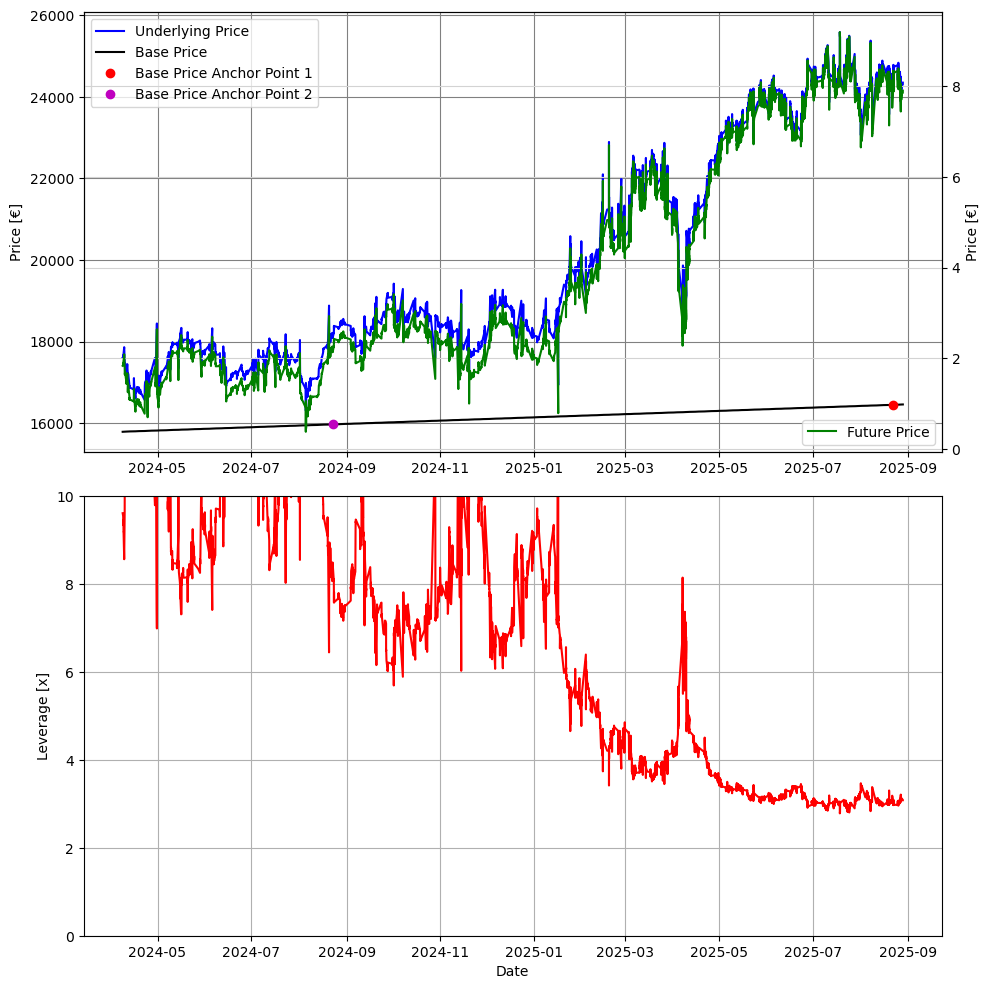

In [24]:
portfolio.by_isin['DE000HS2W424'].plot()

In [10]:
# save adjusted portfolio:
portfolio.save_to_csv(SAVED_PORTFOLIOS / filemgmt.file_title("Scraped Certificate Set", ".csv"))

## Instantiate Artificial Products

In [ ]:
# initialise for 2020/07, 2022/07, 2024/01
portfolio = KOCertificateSet(
    underlying_price_series=data_manager.non_etf_env_interp_prices,
    base_price_inference_timestamps=["2020-07-06 10:00:00", "2022-07-05 10:00:00", "2024-01-05 10:00:00"],
    # "2023-07-05 10:00:00", "2024-07-05 10:00:00", "2025-03-05 10:00:00"],
    n_products_per_direction=15,
    lowest_leverage=1.0, highest_leverage=10.0)

# add several other with more recent issue dates
portfolio.ko_certificates += portfolio.initialise_products_from_leverage(
    underlying_price_series=data_manager.non_etf_env_interp_prices,
    base_price_inference_timestamps=["2017-12-08 10:00:00", "2018-07-05 10:00:00"],
    n_products_per_direction=15, issue_date="2017-01-01 10:00:00",
    lowest_leverage=1.0, highest_leverage=10.0)

portfolio.ko_certificates += portfolio.initialise_products_from_leverage(
    underlying_price_series=data_manager.non_etf_env_interp_prices,
    base_price_inference_timestamps=["2021-07-06 10:00:00", "2023-07-05 10:00:00", "2024-07-05 10:00:00",
                                     "2025-03-05 10:00:00"],
    n_products_per_direction=15, issue_date="2020-06-01 10:00:00",
    lowest_leverage=1.0, highest_leverage=10.0)

portfolio.ko_certificates += portfolio.initialise_products_from_leverage(
    underlying_price_series=data_manager.non_etf_env_interp_prices,
    base_price_inference_timestamps=["2023-05-05 10:00:00", "2024-07-05 10:00:00", "2025-03-05 10:00:00"],
    n_products_per_direction=15, issue_date="2022-12-01 10:00:00",
    lowest_leverage=1.0, highest_leverage=10.0)

portfolio.ko_certificates += portfolio.initialise_products_from_leverage(
    underlying_price_series=data_manager.non_etf_env_interp_prices,
    base_price_inference_timestamps=["2025-03-05 12:00:00"],
    n_products_per_direction=15, issue_date="2024-03-03 10:00:00",
    lowest_leverage=1.0, highest_leverage=10.0)

portfolio.save_to_csv(SAVED_PORTFOLIOS / filemgmt.file_title("Artificial Certificate Set", ".csv"))